In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from ariel_pred.dataset import DataLoaderAndCalibrator
from ariel_pred.preprocessing import SGSmoothing
from ariel_pred.plots import plot_white_curve
from ariel_pred.transit import FunctionFittingBasedPhaseDetector
from ariel_pred.models import TransitMultiplicationFactorFinder, SValuesCNN, SValuesCNNTrainer
from ariel_pred.features import WavelengthsGroupsMultiplierFinder
from ariel_pred.metrics import score, gll
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import random
from scipy.optimize import minimize
from tqdm.auto import tqdm
import pandas as pd
import torch
from torch import nn
import scipy

In [3]:
data_loader = DataLoaderAndCalibrator(
    data_path=Path("../data/raw"),
    output_path=Path("../data/calibrated/full"),
    force_recalibration=False,
    cut_airs_channels=True,
    binning=4,
    n_jobs=4
)
train_data, train_labels = data_loader.load_all_train_data()
train_data.shape, train_labels.shape

Loading calibrated train data...


((1100, 1406, 283), (1100, 283))

In [4]:
features_extractor = WavelengthsGroupsMultiplierFinder()

features = features_extractor.extract_features(
    train_data,
    average_cross_groups=False,
)

features.shape

100%|██████████| 1100/1100 [03:22<00:00,  5.42it/s]


(1100, 283, 7)

In [5]:
cnn_train_data = features.transpose(0, 2,1)
cnn_train_data.shape

(1100, 7, 283)

In [27]:
trainer = SValuesCNNTrainer(
    Path("../models/s_values_cnn"),
    device=torch.device("mps"),
    in_channels=cnn_train_data.shape[1],
    num_channels=283,
    train_multiplier=1.0,
)

res = trainer.train(cnn_train_data, train_labels, n_splits=5, return_predictions=True)

if res is not None:
    spectrum, sigma, (val_rmse, val_gll, val_loss, train_loss) = res # type: ignore

No saved models found in the specified path. Starting training from scratch.


Training Model:   0%|          | 0/1000 [00:00<?, ?it/s]

In [28]:
np.mean((features.mean(axis=2) - train_labels)**2)**0.5, np.mean((spectrum - train_labels)**2)**0.5

(np.float64(0.001371399543845563), np.float64(0.0007380723268915211))

In [29]:
sigma.mean(), sigma.min(), sigma.max()

(np.float64(8.570867659773673e-05),
 np.float64(1.0000000116860974e-07),
 np.float64(0.0018823164282366633))

In [30]:
gll(np.concatenate([spectrum, sigma], axis=1), train_labels)

0.0

In [31]:
spectrum.mean(), spectrum.min(), spectrum.max()

(np.float64(0.014482058469375165),
 np.float64(0.0007718041888438165),
 np.float64(0.09494033455848694))

In [45]:
y_ref = 0.014689019532534079 * np.ones_like(spectrum)
y_ideal = train_labels
sigma_ref = 0.010661335331978338 * np.ones_like(sigma)
sigma_ideal = 1e-5 * np.ones_like(sigma)
sigma_ideal[:, 0] = 1e-6
GLL_Pred = scipy.stats.norm.logpdf(train_labels, loc=spectrum, scale=sigma)
GLL_ref = scipy.stats.norm.logpdf(train_labels, loc=y_ref, scale=sigma_ref)
GLL_ideal = scipy.stats.norm.logpdf(train_labels, loc=y_ideal, scale=sigma_ideal)
ind_scores = (GLL_Pred - GLL_ref) / (GLL_ideal - GLL_ref)

In [46]:
df = pd.DataFrame({
    "original_index": np.repeat(np.arange(spectrum.shape[0]), spectrum.shape[1]),
    "spectrum": spectrum.flatten(),
    "label": train_labels.flatten(),
    "rse": ((spectrum - train_labels)**2).flatten()**0.5,
    "sigma": sigma.flatten().clip(min=1e-5),
    "ind_scores": ind_scores.flatten(),
    "GLL_Pred": GLL_Pred.flatten(),
    "GLL_ref": GLL_ref.flatten(),
    "GLL_ideal": GLL_ideal.flatten(),
})
df.sort_values("ind_scores")

,original_index,spectrum,label,rse,sigma,ind_scores,GLL_Pred,GLL_ref,GLL_ideal
140551,496,0.006772,0.016067,9.295060e-03,0.00001,-6.188844e+08,-4.319907e+09,3.613835,10.593987
140559,496,0.006689,0.015981,9.292010e-03,0.00001,-6.185684e+08,-4.317072e+09,3.614852,10.593987
140560,496,0.006688,0.015977,9.289302e-03,0.00001,-6.182114e+08,-4.314557e+09,3.614891,10.593987
140552,496,0.006766,0.016053,9.287385e-03,0.00001,-6.178783e+08,-4.312776e+09,3.614010,10.593987
140553,496,0.006767,0.016036,9.269750e-03,0.00001,-6.155513e+08,-4.296413e+09,3.614207,10.593987
...,...,...,...,...,...,...,...,...,...
265882,939,0.010774,0.010775,3.851023e-08,0.00001,1.643684e+00,1.512501e+01,3.554787,10.593987
247996,876,0.009838,0.009838,3.094883e-08,0.00001,1.644109e+00,1.515127e+01,3.518664,10.593987
104568,369,0.010895,0.010896,3.374021e-08,0.00001,1.646508e+00,1.514224e+01,3.558889,10.593987
308080,1088,0.011332,0.011332,2.320051e-08,0.00001,1.652046e+00,1.517224e+01,3.572617,10.593987


In [25]:
df.corr()

,original_index,spectrum,sigma,GLL_Pred,GLL_ref,GLL_ideal,ind_scores
original_index,1.000000e+00,0.191913,-2.574507e-01,0.108546,-0.019911,-1.348073e-13,0.110634
spectrum,1.919129e-01,1.000000,-3.683821e-01,0.063815,-0.561536,-3.338200e-04,0.115158
sigma,-2.574507e-01,-0.368382,1.000000e+00,-0.138374,-0.285075,1.974015e-13,-0.109110
GLL_Pred,1.085464e-01,0.063815,-1.383739e-01,1.000000,0.051442,-3.247771e-03,0.995278
GLL_ref,-1.991127e-02,-0.561536,-2.850748e-01,0.051442,1.000000,5.485677e-05,-0.039352
GLL_ideal,-1.348073e-13,-0.000334,1.974015e-13,-0.003248,0.000055,1.000000e+00,-0.006219
ind_scores,1.106341e-01,0.115158,-1.091105e-01,0.995278,-0.039352,-6.218516e-03,1.000000


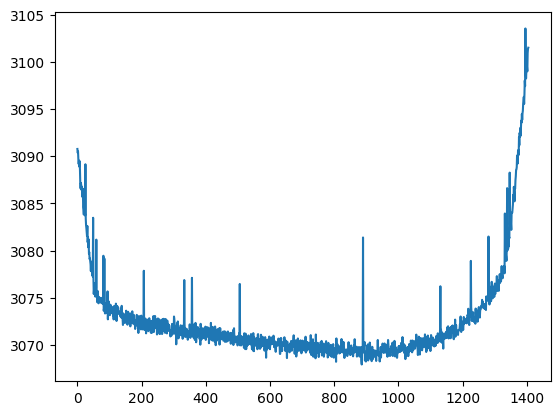

In [37]:
plt.plot(train_data[496].mean(axis=1))

In [23]:
spectrum[42]

array([0.00100637, 0.00100648, 0.0010101 , 0.00101618, 0.00101286,
       0.00101021, 0.00100734, 0.00100928, 0.00101856, 0.00102812,
       0.00103536, 0.00104799, 0.00104893, 0.00104389, 0.00103295,
       0.00102563, 0.00102281, 0.00102744, 0.0010321 , 0.00103858,
       0.00104404, 0.00104661, 0.00104798, 0.00105186, 0.00105694,
       0.00106387, 0.0010777 , 0.00108918, 0.0011051 , 0.00112465,
       0.00113945, 0.00115181, 0.00114956, 0.00114138, 0.00113693,
       0.00113246, 0.00112946, 0.00113343, 0.00113961, 0.00114343,
       0.00114508, 0.00114824, 0.00114722, 0.00114367, 0.00113828,
       0.00113401, 0.00112937, 0.00112418, 0.00111912, 0.00111471,
       0.00111075, 0.00109702, 0.00108286, 0.00106622, 0.00104347,
       0.00102527, 0.00100958, 0.00100051, 0.00099299, 0.00098481,
       0.00097648, 0.00096805, 0.00096851, 0.0009707 , 0.00097961,
       0.0009839 , 0.00099734, 0.00099975, 0.00100064, 0.00100397,
       0.00101804, 0.00103311, 0.00105755, 0.00108831, 0.00111

In [24]:
train_labels[42]

array([0.00638327, 0.00640072, 0.00640165, 0.00640217, 0.0064021 ,
       0.00640141, 0.0064003 , 0.00639903, 0.00639785, 0.00639685,
       0.00639596, 0.0063949 , 0.00639354, 0.00639235, 0.00639221,
       0.00639344, 0.00639501, 0.00639547, 0.00639451, 0.00639298,
       0.00639198, 0.00639201, 0.00639283, 0.00639369, 0.00639397,
       0.00639372, 0.00639351, 0.00639371, 0.00639414, 0.00639453,
       0.00639497, 0.00639562, 0.00639636, 0.00639694, 0.00639733,
       0.00639783, 0.00639855, 0.00639895, 0.00639835, 0.00639683,
       0.00639526, 0.0063943 , 0.00639369, 0.00639288, 0.00639196,
       0.00639141, 0.00639132, 0.00639123, 0.00639073, 0.00639   ,
       0.00638954, 0.00638981, 0.00639106, 0.00639305, 0.00639503,
       0.0063961 , 0.00639597, 0.00639513, 0.00639428, 0.00639376,
       0.00639366, 0.00639401, 0.00639462, 0.00639522, 0.00639565,
       0.00639587, 0.00639571, 0.00639502, 0.00639394, 0.00639285,
       0.00639189, 0.00639104, 0.00639056, 0.00639083, 0.00639